# N8 — Planning

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook trata da sequência de ações que um agente executa para cumprir uma tarefa de várias etapas. Um agente que decide a cada turno guarda essa sequência apenas no histórico de mensagens, depois de executá-la. Os arranjos desta aula gravam a sequência em um campo do estado, escrito antes da primeira chamada de ferramenta, e o código lê, registra e altera esse campo.

As seções vão de um laço que decide um passo por vez até um ciclo que critica e reescreve o plano antes de qualquer execução. A tarefa é a mesma em todas as seções, e os arranjos diferem no momento em que o plano é escrito e no momento em que ele pode mudar: nunca, durante a execução por uma condição sobre a evidência, ou antes de a execução começar.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python: funções, dicionários, listas, anotações de tipo e f-strings;
- declaração de estado com `TypedDict` e construção de grafos com `StateGraph`, `add_node` e `add_edge`;
- roteamento com `add_conditional_edges` e associação de um reducer a um campo do estado com `Annotated`;
- declaração de esquema com Pydantic (`BaseModel` e `Field`) e saída estruturada com `with_structured_output`;
- tool calling, o mecanismo pelo qual o modelo devolve na resposta o nome de uma função declarada e os argumentos dela, e a aplicação executa a função e devolve o retorno ao modelo;
- o par pedido e observação, gravado em `AIMessage.tool_calls` e em `ToolMessage`.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Distinguir a sequência de ações registrada no histórico de mensagens da sequência gravada em um campo do estado.
2. Produzir um plano como lista de passos, com saída estruturada, antes de qualquer execução.
3. Montar em `StateGraph` o ciclo entre planejador, executor e conclusão, com teto de passos.
4. Desviar a execução para um replanejador quando uma condição sobre a evidência coletada for satisfeita.
5. Reescrever os passos pendentes de um plano sem refazer os passos já executados.
6. Escrever um plano ReWOO com referências entre passos, e resolvê-las em um executor sem chamada de modelo.
7. Criticar e revisar um plano antes de a primeira ferramenta ser chamada.
8. Comparar os arranjos pelo número de chamadas de modelo e pelo momento em que o plano pode mudar.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Ferramentas do exemplo.
2. Laço de decisão por turno.
3. Plano como campo do estado.
4. Plan-and-Execute.
5. Replanejamento.
6. ReWOO.
7. Reflexão sobre o plano.
8. Comparação dos arranjos.
9. Exercícios de fixação.
10. Resumo da aula.
11. Referências.

## 0.4 Contexto usado nos exemplos

Os exemplos montam o assistente de um curso de agentes com LLMs. O curso tem seis módulos, de `A4` a `A9`, cada um com um número próprio de aulas de 50 minutos. Os alunos Julio, Renan e Ana têm registrado o módulo em que estão e os minutos de estudo de que dispõem por semana.

A tarefa é a mesma em todas as seções: montar o plano de revisão de Renan para as quatro semanas que faltam até a prova final. Ela precisa de três dados encadeados, e nenhum deles está no texto do pedido. O módulo atual sai da consulta ao progresso, a lista de módulos restantes sai do módulo atual, e a comparação entre carga e tempo disponível sai do total de aulas restantes.

Os números do caso fixam o resultado da comparação. Renan está no `A5`, tem 240 minutos por semana e 23 aulas pela frente, o que dá 1150 minutos de carga contra 960 minutos disponíveis. A carga não cabe no prazo, e essa evidência aciona o replanejador da seção 5.

---

## 0.5 Preparação do ambiente

O notebook usa o modelo `gpt-oss:120b`, executado na infraestrutura do Ollama e acessado pela API em `https://ollama.com`. Nenhum modelo é baixado na máquina. A seção 0.6 registra também a configuração do Gemini, para o caso de a execução ser feita pela API do Google.

As bibliotecas são `langchain` (decorador `@tool`), `langgraph` (grafo, reducers e roteamento), `langchain-ollama` e `langchain-google-genai` (clientes dos dois provedores), `pydantic` (esquemas das saídas estruturadas) e `python-dotenv` (leitura da chave). A célula de imports carrega os dois clientes, então os dois pacotes precisam estar instalados; a constante `PROVEDOR` da seção 0.6 decide qual deles é instanciado.

A execução depende de duas capacidades do modelo. Tool calling é usado pelo executor das seções 2, 4 e 5, e a saída estruturada é usada pelo planejador, pelo replanejador e pelo crítico das seções 4 a 7. O `gpt-oss:120b` e o `gemini-3.5-flash-lite` têm as duas. Um modelo sem saída estruturada devolve prosa onde o grafo espera um objeto, e o nó termina em erro de validação.

O acesso ao modelo hospedado exige uma chave de API. Os passos para obtê-la:

1. Criar uma conta em [ollama.com](https://ollama.com) e entrar nela.
2. Abrir [ollama.com/settings/keys](https://ollama.com/settings/keys) e gerar uma chave nova.
3. Copiar o valor exibido, que aparece uma única vez.
4. Guardar o valor na variável de ambiente `OLLAMA_API_KEY`.

Há três formas de cumprir o passo 4. Em uma máquina local, escreva a linha `OLLAMA_API_KEY=...` em um arquivo `.env` ao lado do notebook, que já está no `.gitignore`, e deixe o `load_dotenv()` da seção 0.6 carregá-la. A segunda forma é exportar a variável no ambiente antes de abrir o notebook. A terceira é a célula comentada abaixo, para o Google Colab. Não escreva a chave no código versionado.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langchain langgraph langchain-ollama langchain-google-genai pydantic python-dotenv

A célula a seguir cobre o caso do Google Colab, onde não há arquivo `.env`. Descomente as três linhas, cole a chave entre as aspas e execute a célula. Torne a comentá-las antes de salvar o notebook, para que a chave não seja gravada no arquivo.

In [2]:
# # Descomente no Google Colab, onde não há arquivo .env.
# import os
# os.environ["OLLAMA_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

Agora importamos os elementos que serão usados ao longo da aula.

In [3]:
import json
import operator
import os
import re

from typing import Annotated, Any, Literal, TypedDict

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain.tools import tool
from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama

from langgraph.graph import START, END, StateGraph
from langgraph.graph.state import CompiledStateGraph

from IPython.display import Image, display

Glossário dos imports:

- `json`: serialização do retorno das ferramentas e leitura das evidências no executor da seção 6;
- `operator`: a função `operator.add`, usada como reducer dos campos de lista do estado;
- `os` e `load_dotenv`: leitura das chaves de API a partir do ambiente ou do arquivo `.env`;
- `re`: expressão regular que reconhece as referências entre passos do plano da seção 6;
- `Annotated`, `Any`, `Literal` e `TypedDict`: associação do reducer, valor de tipo aberto na resolução de referências, conjunto fechado de destinos das rotas e campos do estado;
- `BaseModel` e `Field`: declaração dos esquemas de saída estruturada e da descrição de cada campo;
- `tool`: decorador que converte uma função Python em ferramenta com nome, descrição e esquema;
- `AnyMessage`, `HumanMessage`, `SystemMessage` e `ToolMessage`: tipo comum às mensagens, o pedido do aluno, a instrução fixa e o resultado de uma ferramenta;
- `ChatOllama` e `ChatGoogleGenerativeAI`: clientes dos dois provedores configurados na seção 0.6;
- `StateGraph`, `START` e `END`: construtor do grafo e os nós virtuais de entrada e saída;
- `CompiledStateGraph`, `Image` e `display`: tipo do grafo compilado e exibição do desenho dele.

As duas funções auxiliares abaixo são usadas nas células de exemplo. A primeira exibe o desenho de um grafo compilado; a segunda imprime uma conversa mensagem a mensagem, separando o texto dos pedidos de chamada.

In [4]:
def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))


def mostrar_conversa(mensagens: list[AnyMessage]) -> None:
    """Imprime cada mensagem com o tipo, os pedidos de chamada e o conteúdo."""
    for indice, mensagem in enumerate(mensagens):
        print(f"[{indice}] {type(mensagem).__name__}")

        for chamada in getattr(mensagem, "tool_calls", []):
            print(f"    pedido: {chamada['name']}({chamada['args']})")

        if mensagem.text:
            rotulo = "resultado" if isinstance(mensagem, ToolMessage) else "texto"
            print(f"    {rotulo}: {mensagem.text[:300]}")

        print("-" * 70)

## 0.6 Escolhendo um provedor de LLM

O notebook instancia o modelo por uma função única, `criar_modelo`, e as seções seguintes chamam o objeto devolvido por ela. A constante `PROVEDOR` seleciona qual cliente é construído.

Os dois provedores diferem nos pontos da tabela abaixo, e `criar_modelo` concentra os que afetam a construção do cliente:

| Ponto | Ollama | Gemini |
|---|---|---|
| Classe | `ChatOllama` | `ChatGoogleGenerativeAI` |
| Conexão | `base_url` em `https://ollama.com` e cabeçalho `Authorization` entregue por `client_kwargs` | chave entregue em `api_key` |
| Limite de tokens da resposta | `num_predict` | `max_output_tokens` |
| Amostragem | `temperature`, de 0 a 1 | fixa; a família Gemini 3.x não aceita `temperature`, `top_p` nem `top_k` |
| Raciocínio | `reasoning`, ligado ou desligado | `thinking_level`, com os valores `minimal`, `low`, `medium` e `high` |
| Contagem dos tokens de raciocínio | somados em `usage_metadata["output_tokens"]` | separados em `usage_metadata["output_token_details"]["reasoning"]`, com a chave ausente quando o nível não gasta raciocínio |
| Campo `content` da resposta | uma string | uma lista de blocos |

As duas linhas de raciocínio da tabela têm consequência nos arranjos desta aula. O limite de tokens é por chamada e cobre o raciocínio e a resposta juntos, e o `reasoning=False` do Ollama retira o texto de raciocínio do campo da resposta sem retirar os tokens do orçamento. Quando o orçamento acaba antes da resposta visível, a chamada volta sem texto, o nó grava uma evidência vazia no estado, e as chamadas seguintes recebem essa lacuna no pedido. Os arranjos das seções 4 a 7 fazem entre 2 e 8 chamadas por execução, cada uma com as evidências já acumuladas no pedido, e o valor 2500 de `LIMITE_RESPOSTA` cobre o passo mais longo medido.

O parâmetro `thinking_level` do Gemini ocupa o lugar do booleano `reasoning` do Ollama e define quanto do orçamento é gasto com raciocínio. Na mesma pergunta curta, `thinking_level="low"` devolveu 31 tokens de saída sem bloco de raciocínio, `thinking_level="high"` devolveu 420 tokens, dos quais 398 de raciocínio, e o `gpt-oss:120b` devolveu 278 sem separar as duas partes. O notebook usa `low`, que deixa o orçamento de `LIMITE_RESPOSTA` para a resposta. A interface de tool calling e a de saída estruturada são as mesmas nos dois provedores, e as células das seções 1 a 8 não mudam com a troca de `PROVEDOR`.

As saídas gravadas neste arquivo vêm do Ollama. Os cinco arranjos também foram executados pelo `gemini-3.5-flash-lite`, e as seções 2, 5, 6 e 7 registram no texto o que cada execução produziu nos dois provedores. Para executar pelo Gemini, gere uma chave em [aistudio.google.com/apikey](https://aistudio.google.com/apikey), guarde-a na variável `GOOGLE_API_KEY` e troque o valor de `PROVEDOR`.

In [5]:
load_dotenv()

PROVEDOR = "ollama"  # troque para "gemini" depois de definir GOOGLE_API_KEY

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 2500  # tokens gerados por chamada, raciocínio incluído


def criar_modelo():
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if PROVEDOR == "ollama":
        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if PROVEDOR == "gemini":
        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env "
                "ou no ambiente do sistema."
            )

        # A família Gemini 3.x fixa a amostragem, e temperature não é aceito.
        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {PROVEDOR}. Use 'ollama' ou 'gemini'.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

ollama | ChatOllama


### 0.6.1 Saída estruturada nos dois provedores

O planejador, o replanejador e o crítico das seções 4 a 7 recebem a resposta em campos de um esquema Pydantic. Dois pontos da chamada `with_structured_output` dependem do provedor e ficam concentrados nas duas funções abaixo.

O primeiro é o argumento `method`. O valor padrão do `ChatOllama` pede o esquema JSON diretamente ao modelo, e o `gpt-oss:120b` responde com prosa em vez do objeto, o que termina em erro de parsing. Com `method="function_calling"`, o esquema é declarado como ferramenta e o modelo preenche os argumentos dela, forma que os dois provedores aceitam. O notebook usa esse valor nos dois casos.

O segundo é o retorno vazio. O parser devolve `None` quando a resposta não traz a chamada com os campos preenchidos, e o acesso ao atributo seguinte quebra com `AttributeError` em vez de levantar um erro que nomeie a causa. `invocar_estruturado` repete o pedido quando isso acontece.

**Atenção:** uma instrução de sistema que proíba chamar ferramentas desliga também o preenchimento do esquema, porque com `method="function_calling"` o esquema é uma ferramenta. Os prompts das seções 5 e 7 nomeiam o campo a preencher e não proíbem a chamada.

In [6]:
def criar_estruturado(esquema: type[BaseModel]):
    """Liga um esquema Pydantic ao modelo pelo método que os dois provedores aceitam."""
    return criar_modelo().with_structured_output(esquema, method="function_calling")


def invocar_estruturado(estruturado, mensagens: list[AnyMessage], tentativas: int = 3):
    """Repete o pedido enquanto o parser devolver None, e levanta erro ao esgotar as tentativas."""
    for _ in range(tentativas):
        resultado = estruturado.invoke(mensagens)

        if resultado is not None:
            return resultado

    raise RuntimeError(f"O modelo não preencheu o esquema em {tentativas} tentativas.")

---

# 1. Ferramentas do exemplo

As três ferramentas desta seção dão ao assistente os dados que a tarefa exige. As duas primeiras leem os dicionários do curso, e a terceira faz a comparação entre carga e tempo disponível em Python. As três devolvem string JSON e seguem a mesma convenção de erro: um objeto com a chave `erro` e a lista de valores aceitos, em vez de uma exceção.

A célula abaixo grava o cronograma do curso e o cadastro dos alunos, e define as duas ferramentas de consulta. Os dois dicionários ocupam aqui o lugar que uma API de sistema acadêmico ocuparia em produção, e a assinatura das ferramentas continua a mesma nos dois casos.

In [7]:
MINUTOS_POR_AULA = 50

CRONOGRAMA = {
    "A4": {"titulo": "Estado, nós e transições", "aulas": 4},
    "A5": {"titulo": "Grafos com chamadas de modelo", "aulas": 5},
    "A6": {"titulo": "Ferramentas e agentes", "aulas": 5},
    "A7": {"titulo": "Protocolos de contexto", "aulas": 4},
    "A8": {"titulo": "Skills", "aulas": 3},
    "A9": {"titulo": "Planejamento em agentes", "aulas": 6},
}

ALUNOS = {
    "renan": {"modulo_atual": "A5", "minutos_por_semana": 240},
    "julio": {"modulo_atual": "A8", "minutos_por_semana": 240},
    "ana": {"modulo_atual": "A6", "minutos_por_semana": 300},
}


@tool(parse_docstring=True)
def consultar_progresso(nome_aluno: str) -> str:
    """Consulta o módulo atual de um aluno e os minutos de estudo que ele tem por semana.

    Args:
        nome_aluno: primeiro nome do aluno, como Julio, Renan ou Ana.
    """
    chave = nome_aluno.strip().lower()
    aluno = ALUNOS.get(chave)

    if aluno is None:
        return json.dumps(
            {"erro": "aluno_desconhecido", "alunos_disponiveis": list(ALUNOS)},
            ensure_ascii=False,
        )

    return json.dumps({"aluno": chave, **aluno}, ensure_ascii=False)


@tool(parse_docstring=True)
def consultar_modulos_restantes(modulo_atual: str) -> str:
    """Lista os módulos do curso a partir do módulo atual, com o total de aulas já somado.

    Args:
        modulo_atual: código do módulo em que o aluno está, como A5.
    """
    codigo = modulo_atual.strip().upper()
    codigos = list(CRONOGRAMA)

    if codigo not in codigos:
        return json.dumps(
            {"erro": "modulo_desconhecido", "modulos_disponiveis": codigos},
            ensure_ascii=False,
        )

    restantes = [{"codigo": c, **CRONOGRAMA[c]} for c in codigos[codigos.index(codigo):]]

    return json.dumps(
        {
            "modulos_restantes": restantes,
            "total_de_aulas": sum(modulo["aulas"] for modulo in restantes),
        },
        ensure_ascii=False,
    )


print(consultar_progresso.invoke({"nome_aluno": "Renan"}))
print(consultar_modulos_restantes.invoke({"modulo_atual": "A5"}))

{"aluno": "renan", "modulo_atual": "A5", "minutos_por_semana": 240}
{"modulos_restantes": [{"codigo": "A5", "titulo": "Grafos com chamadas de modelo", "aulas": 5}, {"codigo": "A6", "titulo": "Ferramentas e agentes", "aulas": 5}, {"codigo": "A7", "titulo": "Protocolos de contexto", "aulas": 4}, {"codigo": "A8", "titulo": "Skills", "aulas": 3}, {"codigo": "A9", "titulo": "Planejamento em agentes", "aulas": 6}], "total_de_aulas": 23}


## 1.1 Comparação entre carga e prazo

A terceira ferramenta recebe o total de aulas, os minutos por semana e o número de semanas, e devolve os dois totais junto com o campo `cabe`. Esse campo é um booleano calculado em Python, e a rota da seção 5 o lê da string JSON sem chamar o modelo.

In [8]:
@tool(parse_docstring=True)
def calcular_folga(quantidade_aulas: int, minutos_por_semana: int, semanas: int) -> str:
    """Compara a carga de um conjunto de aulas de 50 minutos com o tempo disponível.

    Args:
        quantidade_aulas: número de aulas a estudar.
        minutos_por_semana: minutos de estudo disponíveis por semana.
        semanas: número de semanas até a prova.
    """
    carga = quantidade_aulas * MINUTOS_POR_AULA
    disponivel = minutos_por_semana * semanas

    return json.dumps(
        {
            "carga_minutos": carga,
            "tempo_disponivel_minutos": disponivel,
            "cabe": carga <= disponivel,
            "diferenca_minutos": disponivel - carga,
        },
        ensure_ascii=False,
    )


FERRAMENTAS_CURSO = [consultar_progresso, consultar_modulos_restantes, calcular_folga]
FERRAMENTAS_POR_NOME = {ferramenta.name: ferramenta for ferramenta in FERRAMENTAS_CURSO}

print(calcular_folga.invoke({"quantidade_aulas": 23, "minutos_por_semana": 240, "semanas": 4}))
print(calcular_folga.invoke({"quantidade_aulas": 9, "minutos_por_semana": 240, "semanas": 4}))

{"carga_minutos": 1150, "tempo_disponivel_minutos": 960, "cabe": false, "diferenca_minutos": -190}
{"carga_minutos": 450, "tempo_disponivel_minutos": 960, "cabe": true, "diferenca_minutos": 510}


## 1.2 Tarefa e catálogo em texto

Os planejadores das seções 4 a 7 escrevem o plano sem executá-lo, então recebem a lista de ferramentas como texto no prompt, e não por `bind_tools`. A constante `FERRAMENTAS_TEXTO` guarda esse catálogo, com o nome de cada ferramenta e os campos que ela devolve.

A tarefa fica em `TAREFA`, como string única reenviada em cada seção como mensagem do usuário. As seções 2 e 4 a 7 recebem esse mesmo texto, e a tabela da seção 8 compara os arranjos sobre a mesma entrada.

In [9]:
FERRAMENTAS_TEXTO = """- consultar_progresso(nome_aluno): devolve modulo_atual e minutos_por_semana
- consultar_modulos_restantes(modulo_atual): devolve modulos_restantes e total_de_aulas
- calcular_folga(quantidade_aulas, minutos_por_semana, semanas): devolve carga_minutos,
  tempo_disponivel_minutos, cabe e diferenca_minutos"""

TAREFA = (
    "Sou o Renan. Monte um plano de revisão para as 4 semanas que faltam para a prova "
    "final, considerando meu progresso e os módulos que ainda não estudei."
)

print(FERRAMENTAS_TEXTO)
print("-" * 70)
print(TAREFA)

- consultar_progresso(nome_aluno): devolve modulo_atual e minutos_por_semana
- consultar_modulos_restantes(modulo_atual): devolve modulos_restantes e total_de_aulas
- calcular_folga(quantidade_aulas, minutos_por_semana, semanas): devolve carga_minutos,
  tempo_disponivel_minutos, cabe e diferenca_minutos
----------------------------------------------------------------------
Sou o Renan. Monte um plano de revisão para as 4 semanas que faltam para a prova final, considerando meu progresso e os módulos que ainda não estudei.


## 1.3 Discussão

As três ferramentas cobrem os três dados que a tarefa encadeia:

| Ferramenta | Fonte | Papel na tarefa |
|---|---|---|
| `consultar_progresso` | dicionário `ALUNOS` | módulo atual e minutos por semana |
| `consultar_modulos_restantes` | dicionário `CRONOGRAMA` | módulos pendentes e total de aulas |
| `calcular_folga` | cálculo em Python | comparação entre carga e tempo, com o campo `cabe` |

A dependência entre elas torna a tarefa um caso de planejamento. O argumento de `consultar_modulos_restantes` vem do resultado de `consultar_progresso`, e dois argumentos de `calcular_folga` vêm dos resultados das duas anteriores. Um plano escrito antes da execução precisa expressar essa ordem, e a seção 6 a expressa com referências entre passos.

O campo `cabe` sai de uma comparação em Python, e não de um número que o modelo escreveu. Ele é a evidência que a rota da seção 5 avalia para desviar a execução ao replanejador.

---

# 2. Laço de decisão por turno

O laço abaixo chama o modelo com as ferramentas ligadas, executa os pedidos que a resposta trouxer, acrescenta as observações ao histórico e repete. Cada decisão usa a última observação, e o modelo escolhe a ferramenta seguinte depois de receber o resultado da anterior.

```text
pergunta
  ↓
modelo com ferramentas ligadas  ←──────────┐
  ↓                                        │
AIMessage com tool_calls                   │
  ↓                                        │
aplicação executa as funções               │
  ↓                                        │
ToolMessage com o resultado ───────────────┘
  ↓ (resposta sem pedidos)
AIMessage final
```

A célula soma os tokens de saída das chamadas do laço, para comparar o custo com o dos arranjos das seções seguintes. A contagem vem de `usage_metadata`, preenchido na resposta pelos dois provedores.

In [10]:
PROMPT_TURNO = """Atue como assistente do curso de agentes com LLMs.
Use as ferramentas disponíveis para responder ao aluno.
Responda em português, em no máximo cinco frases."""


def laco_por_turno(pergunta: str, limite_turnos: int = 5) -> tuple[list[AnyMessage], int]:
    """Alterna chamadas ao modelo e execuções de ferramenta até a resposta sem pedidos."""
    modelo_com_ferramentas = modelo.bind_tools(FERRAMENTAS_CURSO)
    mensagens: list[AnyMessage] = [SystemMessage(PROMPT_TURNO), HumanMessage(pergunta)]
    tokens = 0

    for _ in range(limite_turnos):
        resposta = modelo_com_ferramentas.invoke(mensagens)
        mensagens.append(resposta)
        tokens += resposta.usage_metadata["output_tokens"]

        if not resposta.tool_calls:
            break

        for chamada in resposta.tool_calls:
            observacao = FERRAMENTAS_POR_NOME[chamada["name"]].invoke(chamada["args"])
            mensagens.append(ToolMessage(content=observacao, tool_call_id=chamada["id"]))

    return mensagens, tokens


mensagens_turno, tokens_turno = laco_por_turno(TAREFA)

mostrar_conversa(mensagens_turno)
print("tokens de saída somados:", tokens_turno)

[0] SystemMessage
    texto: Atue como assistente do curso de agentes com LLMs.
Use as ferramentas disponíveis para responder ao aluno.
Responda em português, em no máximo cinco frases.
----------------------------------------------------------------------
[1] HumanMessage
    texto: Sou o Renan. Monte um plano de revisão para as 4 semanas que faltam para a prova final, considerando meu progresso e os módulos que ainda não estudei.
----------------------------------------------------------------------
[2] AIMessage
    pedido: consultar_progresso({'nome_aluno': 'Renan'})
----------------------------------------------------------------------
[3] ToolMessage
    resultado: {"aluno": "renan", "modulo_atual": "A5", "minutos_por_semana": 240}
----------------------------------------------------------------------
[4] AIMessage
    pedido: consultar_modulos_restantes({'modulo_atual': 'A5'})
----------------------------------------------------------------------
[5] ToolMessage
    resultado: {

## 2.1 Leitura da execução

A execução gravada percorreu esta sequência:

1. A primeira chamada devolve uma `AIMessage` com o pedido de `consultar_progresso`, e a observação traz `modulo_atual` igual a `A5`.
2. A segunda chamada usa esse valor como argumento de `consultar_modulos_restantes`, e a observação traz `total_de_aulas` igual a 23.
3. A terceira chamada usa esse total em `calcular_folga`, e a observação traz `cabe` igual a `false`.
4. A quarta chamada volta sem pedidos, e o texto dela é a resposta ao aluno.

Cada argumento saiu do resultado da consulta anterior, e o modelo emitiu um pedido por resposta. A contagem de tokens somada ao final cobre as quatro chamadas.

A execução desta célula pelo `gemini-3.5-flash-lite` emitiu os mesmos três pedidos, na mesma ordem, e somou 204 tokens de saída contra os 605 do `gpt-oss:120b`. A diferença está no raciocínio: com `thinking_level="low"` o Gemini gera menos tokens de raciocínio por chamada que o `gpt-oss:120b`, e nos dois provedores esses tokens entram em `output_tokens`.

## 2.2 Discussão

O estado deste laço é a lista de mensagens. A sequência de ações existe nela depois de executada: a terceira consulta aparece no histórico porque já foi feita, e nenhuma mensagem anterior a anuncia.

Isso fixa três propriedades do arranjo. A aplicação não tem o que registrar antes da primeira chamada de ferramenta, porque a lista de passos não existe como valor. Uma alteração na sequência passa por alterar o prompt e chamar o modelo de novo, já que o único artefato editável é o texto das mensagens. O número de chamadas segue o número de passos, porque cada passo custa uma chamada com o histórico inteiro no pedido.

As seções 4 a 7 mudam esse ponto: o campo `plano` do estado guarda a lista de passos, escrita antes da execução, como valor Python que o código lê e altera. A seção 3 descreve esse campo antes do primeiro grafo que o usa.

---

# 3. Plano como campo do estado

Um **plano** é uma lista ordenada de passos gravada em um campo do estado. Ele é produzido por uma chamada de modelo com saída estruturada, antes de qualquer ferramenta ser executada, e o executor consome um item por vez.

```text
tarefa
  ↓
planejador  →  plano: ["passo 1", "passo 2", "passo 3"]   ← campo do estado
                  ↓
              executor consome um item por vez
                  ↓
              conclusão
```

Duas propriedades vêm dessa mudança de lugar. O plano é legível antes da execução, então a aplicação pode registrá-lo, exibi-lo ou submetê-lo a aprovação. O plano é um valor Python, então alterá-lo é atribuir uma lista nova ao campo, sem passar pelo texto de um prompt.

Os quatro arranjos das seções seguintes usam esse campo e diferem no momento em que ele pode mudar:

| Arranjo | Plano escrito | Plano alterado depois de escrito |
|---|---|---|
| Plan-and-Execute (seção 4) | em uma chamada, antes da execução | não é alterado |
| Replanejamento (seção 5) | em uma chamada, antes da execução | durante a execução, quando uma condição sobre a evidência é satisfeita |
| ReWOO (seção 6) | em uma chamada, com as dependências declaradas | não é alterado, e nenhuma observação chega ao planejador |
| Reflexão sobre o plano (seção 7) | em uma chamada por versão | entre as versões, antes de a execução começar |

---

# 4. Plan-and-Execute

O arranjo separa três papéis em três nós. O planejador lê a tarefa e escreve a lista de passos. O executor toma o próximo passo pendente e chama a ferramenta que ele pedir. A conclusão escreve a resposta ao aluno a partir das evidências reunidas.

```text
START → planejar → executar → decidir_proximo_no
                                   ├── executar → decidir_proximo_no
                                   └── concluir → END
```

O estado tem cinco campos. O campo `plano` recebe a lista inteira de uma vez. Os campos `passos_feitos` e `evidencias` crescem um item por execução, e o reducer `operator.add` concatena o item novo ao que já estava no estado, o que deixa o nó devolvendo apenas o que produziu.

In [11]:
class EstadoPlano(TypedDict):
    tarefa: str
    plano: list[str]
    passos_feitos: Annotated[list[str], operator.add]
    evidencias: Annotated[list[str], operator.add]
    resposta: str


class Plano(BaseModel):
    """Lista ordenada de passos para cumprir a tarefa."""

    passos: list[str] = Field(
        description="Passos em ordem, um texto por item, cada um resolvível com uma ferramenta."
    )


PROMPT_PLANEJADOR = f"""Monte um plano com no máximo 4 passos para cumprir a tarefa do aluno.
Ferramentas disponíveis ao executor:
{FERRAMENTAS_TEXTO}
Cada passo é uma frase em português que diz o que obter e com qual ferramenta. O último passo
sintetiza a resposta ao aluno e não usa ferramenta.
Preencha o campo passos e não execute nenhum deles."""


def no_planejar(state: EstadoPlano) -> dict:
    """Escreve a lista de passos antes de qualquer execução."""
    plano = invocar_estruturado(criar_estruturado(Plano), [
        SystemMessage(PROMPT_PLANEJADOR),
        HumanMessage(state["tarefa"]),
    ])

    return {"plano": plano.passos}

## 4.1 Executor e conclusão

O executor localiza o passo atual pelo tamanho de `passos_feitos`: com dois passos executados, o passo atual é `plano[2]`. Ele recebe a tarefa, as evidências já coletadas e o texto do passo, e devolve o retorno das ferramentas que pedir. Um passo que não peça ferramenta grava o próprio texto da resposta como evidência.

O teto `LIMITE_PASSOS` encerra a execução pela contagem de passos executados, independentemente do conteúdo do plano. Ele existe porque o replanejador da seção 5 reescreve a lista, e um plano que cresce a cada revisão precisa de um limite que não dependa do próprio plano.

In [12]:
PROMPT_EXECUTOR = """Execute apenas o passo atual do plano, chamando uma ferramenta quando o
passo pedir um dado. Considere as evidências já coletadas. Responda em português."""

PROMPT_SINTESE = """Escreva a resposta final ao aluno a partir das evidências coletadas.
Diga se o conteúdo cabe no tempo disponível e distribua os módulos pelas semanas.
Responda em português, em no máximo seis frases."""

LIMITE_PASSOS = 6

modelo_executor = modelo.bind_tools(FERRAMENTAS_CURSO)


def formatar_evidencias(state: EstadoPlano) -> str:
    """Junta cada passo executado ao que ele produziu, em uma linha por par."""
    linhas = [
        f"- {passo}: {evidencia}"
        for passo, evidencia in zip(state["passos_feitos"], state["evidencias"])
    ]

    return "\n".join(linhas) or "nenhum passo executado ainda"


def no_executar(state: EstadoPlano) -> dict:
    """Executa o próximo passo pendente e grava o que ele produziu."""
    passo = state["plano"][len(state["passos_feitos"])]

    resposta = modelo_executor.invoke([
        SystemMessage(PROMPT_EXECUTOR),
        HumanMessage(
            f"Tarefa: {state['tarefa']}\n\nEvidências:\n{formatar_evidencias(state)}\n\n"
            f"Passo atual: {passo}"
        ),
    ])

    observacoes = [
        FERRAMENTAS_POR_NOME[chamada["name"]].invoke(chamada["args"])
        for chamada in resposta.tool_calls
        if chamada["name"] in FERRAMENTAS_POR_NOME
    ]

    return {"passos_feitos": [passo], "evidencias": [" ".join(observacoes) or resposta.text]}


def no_concluir(state: EstadoPlano) -> dict:
    """Escreve a resposta ao aluno a partir das evidências reunidas."""
    resposta = modelo.invoke([
        SystemMessage(PROMPT_SINTESE),
        HumanMessage(f"Tarefa: {state['tarefa']}\n\nEvidências:\n{formatar_evidencias(state)}"),
    ])

    return {"resposta": resposta.text}

## 4.2 Rota e montagem do grafo

A rota compara o número de passos executados com o tamanho do plano e com o teto. Ela é a única parte do arranjo que decide sem chamar o modelo.

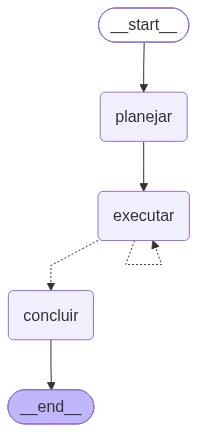

In [13]:
def decidir_proximo_no(state: EstadoPlano) -> Literal["executar", "concluir"]:
    """Continua enquanto restar passo pendente e o teto não for atingido."""
    feitos = len(state["passos_feitos"])

    if feitos < len(state["plano"]) and feitos < LIMITE_PASSOS:
        return "executar"

    return "concluir"


builder = StateGraph(EstadoPlano)

builder.add_node("planejar", no_planejar)
builder.add_node("executar", no_executar)
builder.add_node("concluir", no_concluir)

builder.add_edge(START, "planejar")
builder.add_edge("planejar", "executar")

builder.add_conditional_edges(
    "executar",
    decidir_proximo_no,
    {"executar": "executar", "concluir": "concluir"},
)

builder.add_edge("concluir", END)

graph_plano = builder.compile()

display_graph(graph_plano)

## 4.3 Execução do agente

A entrada inicia os cinco campos do estado. Os dois campos com reducer começam como lista vazia, porque `operator.add` concatena ao valor que já está no estado.

In [14]:
entrada = {
    "tarefa": TAREFA,
    "plano": [],
    "passos_feitos": [],
    "evidencias": [],
    "resposta": "",
}

resultado = graph_plano.invoke(entrada)

print("PLANO")
for indice, passo in enumerate(resultado["plano"], start=1):
    print(f"  {indice}. {passo}")

print("-" * 70)
print("EVIDÊNCIAS")
for passo, evidencia in zip(resultado["passos_feitos"], resultado["evidencias"]):
    print(f"  {passo}\n     {evidencia[:200]}")

print("-" * 70)
print("RESPOSTA")
print(resultado["resposta"])

PLANO
  1. Obter o módulo atual e os minutos disponíveis por semana do aluno Renan usando a ferramenta consultar_progresso("Renan").
  2. Com o módulo atual obtido, consultar os módulos restantes e o total de aulas usando a ferramenta consultar_modulos_restantes(modulo_atual).
  3. Calcular a folga de tempo para as 4 semanas restantes usando a ferramenta calcular_folga(total_de_aulas, minutos_por_semana, 4).
  4. Com base nos resultados, montar um plano de revisão detalhado para as 4 semanas, indicando quantas aulas estudar por semana e ajustes caso o tempo não seja suficiente.
----------------------------------------------------------------------
EVIDÊNCIAS
  Obter o módulo atual e os minutos disponíveis por semana do aluno Renan usando a ferramenta consultar_progresso("Renan").
     {"aluno": "renan", "modulo_atual": "A5", "minutos_por_semana": 240}
  Com o módulo atual obtido, consultar os módulos restantes e o total de aulas usando a ferramenta consultar_modulos_restantes(modulo_at

## 4.4 Leitura da execução

O plano gravado tem quatro passos, e os três primeiros nomeiam uma ferramenta cada, na ordem de dependência da seção 1.3. O planejador escreveu essa ordem sem executar nada: ele recebeu o catálogo `FERRAMENTAS_TEXTO` no prompt e o texto da tarefa, e devolveu as quatro frases em uma chamada.

As evidências mostram o que cada passo produziu. As três primeiras são as strings JSON das ferramentas, e a última é o texto que o modelo escreveu para o passo de síntese, que não pede ferramenta. O nó `executar` rodou quatro vezes, uma por passo: a rota devolveu `executar` nas três primeiras decisões e `concluir` na quarta, quando `passos_feitos` alcançou o tamanho do plano.

O executor recebeu o texto do passo, sem a instrução de chamar uma ferramenta específica. A escolha da ferramenta continua com o modelo, que a faz pela descrição declarada em cada uma; ao plano cabe a ordem dos passos e o objetivo de cada um.

## 4.5 Discussão

O plano existe como valor antes da primeira chamada de ferramenta, e isso o torna inspecionável. Entre o nó `planejar` e o nó `executar` pode entrar um código que leia `state["plano"]`: um registro em log, uma exibição ao usuário, ou uma interrupção que espere aprovação antes de seguir.

A ordem dos passos é fixada em uma chamada e não muda durante a execução deste grafo. Uma evidência que contrarie a premissa do plano chega ao executor pelo contexto, e o executor a usa dentro do passo que recebeu; a lista de passos pendentes continua a mesma. A seção 5 acrescenta o nó que reescreve essa lista.

O custo em chamadas de modelo é uma para o plano, uma por passo executado e uma para a conclusão. Na execução gravada são seis chamadas, contra quatro do laço da seção 2 para a mesma tarefa.

---

# 5. Replanejamento

O grafo desta seção acrescenta um nó `replanejar` entre a execução e a decisão. Ele é alcançado por uma condição sobre as evidências já coletadas, e reescreve os passos que ainda faltam.

```text
START → planejar → executar → decidir_com_replano
                                   ├── executar   → decidir_com_replano
                                   ├── replanejar → decidir_com_replano
                                   └── concluir   → END
```

O gatilho é determinístico. A função `carga_nao_cabe` procura o campo `"cabe": false` nas strings JSON gravadas em `evidencias`, sem chamar o modelo. Com os números da seção 0.4, a terceira evidência traz esse campo, e o desvio acontece nesse ponto da execução.

O campo `replanejado` guarda se o desvio já ocorreu. Sem ele, a condição continuaria satisfeita depois da revisão e a rota voltaria ao replanejador a cada volta.

In [15]:
class EstadoReplano(EstadoPlano):
    replanejado: bool


class Replano(BaseModel):
    """Passos que ainda faltam, revistos depois das evidências coletadas."""

    passos_restantes: list[str] = Field(
        description="Passos que ainda precisam ser executados, em ordem, um texto por item."
    )


PROMPT_REPLANEJADOR = """Reescreva os passos que ainda faltam do plano, a partir das evidências
já coletadas. As evidências mostram que a carga do aluno não cabe no tempo disponível, então os
passos restantes precisam incluir a escolha de quais módulos ficam dentro desse tempo.
Escreva no máximo 2 passos, cada um em uma frase em português. Descarte os passos pendentes que
as evidências já responderam. O último passo apresenta o plano ao aluno.
Preencha o campo passos_restantes."""


def no_replanejar(state: EstadoReplano) -> dict:
    """Troca os passos pendentes do plano pelos que o modelo reescreveu."""
    pendentes = state["plano"][len(state["passos_feitos"]):]

    revisao = invocar_estruturado(criar_estruturado(Replano), [
        SystemMessage(PROMPT_REPLANEJADOR),
        HumanMessage(
            f"Tarefa: {state['tarefa']}\n\nEvidências:\n{formatar_evidencias(state)}\n\n"
            "Passos pendentes:\n" + ("\n".join(f"- {passo}" for passo in pendentes) or "nenhum")
        ),
    ])

    return {
        "plano": state["passos_feitos"] + (revisao.passos_restantes or pendentes),
        "replanejado": True,
    }

## 5.1 Rota com três destinos

A rota devolve um de três destinos e é usada nas saídas de dois nós, `executar` e `replanejar`. Depois da revisão, `replanejado` está em `True`, a primeira condição falha, e a mesma função encaminha a execução ao próximo passo do plano novo.

O nó `replanejar` preserva os passos já executados: ele devolve `passos_feitos` concatenado aos passos reescritos, e o índice que o executor calcula continua apontando para o primeiro pendente. A revisão alcança apenas a parte do plano que ainda não produziu evidência.

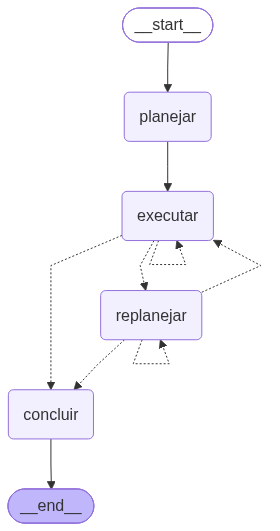

In [16]:
def carga_nao_cabe(state: EstadoReplano) -> bool:
    """Indica se alguma evidência registrou que a carga excede o tempo disponível."""
    return any('"cabe": false' in evidencia for evidencia in state["evidencias"])


def decidir_com_replano(state: EstadoReplano) -> Literal["replanejar", "executar", "concluir"]:
    """Desvia uma vez ao replanejador quando a carga não couber, e segue o plano depois."""
    feitos = len(state["passos_feitos"])

    if carga_nao_cabe(state) and not state["replanejado"]:
        return "replanejar"

    if feitos < len(state["plano"]) and feitos < LIMITE_PASSOS:
        return "executar"

    return "concluir"


DESTINOS = {"replanejar": "replanejar", "executar": "executar", "concluir": "concluir"}

builder = StateGraph(EstadoReplano)

builder.add_node("planejar", no_planejar)
builder.add_node("executar", no_executar)
builder.add_node("replanejar", no_replanejar)
builder.add_node("concluir", no_concluir)

builder.add_edge(START, "planejar")
builder.add_edge("planejar", "executar")

builder.add_conditional_edges("executar", decidir_com_replano, DESTINOS)
builder.add_conditional_edges("replanejar", decidir_com_replano, DESTINOS)

builder.add_edge("concluir", END)

graph_replano = builder.compile()

display_graph(graph_replano)

## 5.2 Execução com o desvio

A execução é acompanhada com `stream_mode="updates"`, que emite um evento por nó executado. A saída imprime o plano inteiro sempre que o campo muda, o que registra a lista antes e depois da revisão.

In [17]:
entrada = {
    "tarefa": TAREFA,
    "plano": [],
    "passos_feitos": [],
    "evidencias": [],
    "resposta": "",
    "replanejado": False,
}

for evento in graph_replano.stream(entrada, stream_mode="updates"):
    for no, atualizacao in evento.items():
        if "plano" in atualizacao:
            print(f"{no:11} | plano com {len(atualizacao['plano'])} passos")
            for indice, passo in enumerate(atualizacao["plano"], start=1):
                print(f"            {indice}. {passo}")

        if "passos_feitos" in atualizacao:
            print(f"{no:11} | executou: {atualizacao['passos_feitos'][0][:90]}")
            print(f"            {atualizacao['evidencias'][0][:160]}")

        if "resposta" in atualizacao:
            print(f"{no:11} | {atualizacao['resposta'][:300]}")

planejar    | plano com 4 passos
            1. Obter o módulo atual e os minutos disponíveis por semana do aluno Renan usando a ferramenta consultar_progresso("Renan").
            2. Com base no módulo atual obtido, consultar os módulos restantes e o total de aulas usando a ferramenta consultar_modulos_restantes(modulo_atual).
            3. Calcular a folga de tempo para as 4 semanas restantes usando a ferramenta calcular_folga(quantidade_aulas, minutos_por_semana, 4), onde quantidade_aulas vem do passo anterior e minutos_por_semana do primeiro passo.
            4. Com base nas informações coletadas, montar e apresentar ao aluno Renan um plano de revisão detalhado para as 4 semanas que faltam, distribuindo as aulas restantes de forma equilibrada dentro da carga horária disponível.
executar    | executou: Obter o módulo atual e os minutos disponíveis por semana do aluno Renan usando a ferrament
            {"aluno": "renan", "modulo_atual": "A5", "minutos_por_semana": 240}
executar 

## 5.3 Leitura da execução

A sequência gravada tem três fases. O nó `planejar` escreveu quatro passos, os três primeiros de consulta e o último de síntese. O nó `executar` rodou três vezes, e a terceira evidência trouxe `"cabe": false`, com 1150 minutos de carga contra 960 disponíveis.

Nesse ponto a rota devolveu `replanejar`. O nó reescreveu a lista: os três passos executados foram preservados, o passo de síntese pendente saiu, e entraram dois passos novos, um que escolhe os módulos que cabem nos 960 minutos e um que apresenta o plano. O campo `plano` passou de quatro para cinco itens.

Depois da revisão, `replanejado` ficou em `True`, e a mesma rota encaminhou a execução aos dois passos novos, na ordem. O nó `concluir` escreveu a resposta com as cinco evidências no pedido.

O passo que entrou no plano não estava na lista original. Ele foi acrescentado por causa de um valor que só existiu depois da terceira execução, e o replanejador o escreveu com essa evidência no pedido.

A execução pelo `gemini-3.5-flash-lite` seguiu o mesmo percurso: desvio na terceira evidência, plano de quatro para cinco passos, e um passo novo que seleciona os módulos que cabem nos 960 minutos. O gatilho não depende do provedor, porque `carga_nao_cabe` lê o campo `cabe` gravado pela ferramenta.

## 5.4 Discussão

A lista de passos tem papéis diferentes nos dois grafos. Na seção 4 ela é escrita uma vez e consumida até o fim. Aqui ela é um campo que um nó reescreve durante a execução, e o executor lê a versão corrente a cada volta.

A condição de desvio fica fora do modelo. `carga_nao_cabe` é uma função Python sobre o texto das evidências, e o replanejador só é chamado quando ela devolve `True`, o que custa uma chamada de modelo em vez de uma por passo. Uma condição avaliada pelo modelo a cada passo daria ao arranjo o custo de uma chamada extra por volta, e o resultado dependeria da resposta dele.

O teto `LIMITE_PASSOS` limita este grafo por uma contagem que não depende do plano. O tamanho da lista não é conhecido no início, porque o replanejador pode devolver mais passos do que retirou, e a rota compara `passos_feitos` com o teto além do tamanho da lista. Na execução gravada o plano chegou a cinco passos e o teto de seis não foi atingido; o exercício 1 reduz o teto e observa o corte.

---

# 6. ReWOO

ReWOO é a sigla de *Reasoning WithOut Observation*. O planejador escreve o plano inteiro em uma chamada e não recebe nenhuma observação: as dependências entre passos ficam declaradas no próprio plano, por referências a resultados que ainda não existem.

Uma referência tem duas formas. `#E1` designa o resultado inteiro do passo que gravou essa variável, e `#E1['campo']` designa um campo desse resultado. O executor as substitui pelos valores no momento da chamada.

```text
#E1 = consultar_progresso(nome_aluno="Renan")
#E2 = consultar_modulos_restantes(modulo_atual=#E1['modulo_atual'])
#E3 = calcular_folga(quantidade_aulas=#E2['total_de_aulas'], ...)
```

O grafo tem três nós em linha, sem ciclo:

```text
START → planejar → executar_plano → responder → END
         (modelo)   (sem modelo)     (modelo)
```

In [18]:
class ArgumentoReWOO(BaseModel):
    """Um argumento de ferramenta: o nome do parâmetro e o valor."""

    nome: str = Field(description="Nome do parâmetro da ferramenta.")
    valor: str = Field(
        description="Valor do parâmetro: um literal, ou uma referência como #E1 "
        "ou #E1['campo'] a um passo anterior."
    )


class PassoReWOO(BaseModel):
    """Um passo do plano: a variável de saída, a ferramenta e os argumentos."""

    variavel: str = Field(description="Nome da variável do resultado, no formato #E1, #E2.")
    ferramenta: str = Field(description="Nome da ferramenta chamada neste passo.")
    argumentos: list[ArgumentoReWOO] = Field(
        description="Lista de objetos, cada um com as chaves nome e valor, ambas em texto."
    )


class PlanoReWOO(BaseModel):
    """Plano completo, com uma variável por passo."""

    passos: list[PassoReWOO] = Field(description="Passos do plano, em ordem.")


class EstadoReWOO(TypedDict):
    tarefa: str
    plano: list[PassoReWOO]
    evidencias: dict[str, str]
    resposta: str

## 6.1 Prompt do planejador

O esquema acima é aninhado: `PlanoReWOO` tem uma lista de `PassoReWOO`, e cada passo tem uma lista de `ArgumentoReWOO`. Com o `gpt-oss:120b`, a descrição declarada no `Field` não basta para o nível interno, e a lista de argumentos vem preenchida com strings em vez de objetos, o que a validação do Pydantic recusa. A instrução de sistema repete os nomes das chaves do objeto interno, e a execução passa a produzir os objetos.

O prompt também restringe o plano às ferramentas. Sem essa linha, o modelo acrescenta um passo final de síntese sem ferramenta e escreve uma lista no campo `valor`, que está declarado como texto.

Com o `gemini-3.5-flash-lite`, o mesmo prompt produz os objetos do nível interno. O cliente do Google emite o aviso `Key '$defs' is not supported in schema, ignoring` ao converter o esquema aninhado para o formato de declaração de ferramenta dele, e o plano devolvido tem os mesmos campos.

In [19]:
PROMPT_PLANEJADOR_REWOO = f"""Monte de uma vez o plano inteiro para a tarefa do aluno.
Ferramentas disponíveis:
{FERRAMENTAS_TEXTO}
Todo passo chama uma das ferramentas acima. Não crie passo de síntese: a resposta ao aluno é
escrita depois, fora do plano.
Cada passo tem uma variável de saída (#E1, #E2, ...), o nome da ferramenta e a lista de
argumentos. Cada argumento é um objeto com as chaves nome e valor, ambas em texto.
O valor é sempre um texto: um literal, ou a referência #E1 ao resultado inteiro de um passo
anterior, ou a referência #E1['campo'] a um campo desse resultado. Não escreva listas, fórmulas
nem contas no valor.
Exemplo de passo: variavel="#E2", ferramenta="consultar_modulos_restantes",
argumentos=[{{"nome": "modulo_atual", "valor": "#E1['modulo_atual']"}}]."""


def no_planejar_rewoo(state: EstadoReWOO) -> dict:
    """Produz o plano inteiro em uma chamada de modelo."""
    plano = invocar_estruturado(criar_estruturado(PlanoReWOO), [
        SystemMessage(PROMPT_PLANEJADOR_REWOO),
        HumanMessage(state["tarefa"]),
    ])

    return {"plano": plano.passos}

## 6.2 Resolução das referências

O executor deste arranjo não chama o modelo. Ele percorre os passos na ordem, resolve cada argumento contra as evidências já gravadas e chama a ferramenta.

A expressão regular reconhece as duas formas de referência e devolve a variável e o campo opcional. Um valor que não case com ela é um literal e segue como está. A conversão de tipo fica com o Pydantic da própria ferramenta, que aceita o texto `"23"` no parâmetro declarado como `int`.

In [20]:
REFERENCIA = re.compile(r"^(#E\d+)(?:\[['\"]?(\w+)['\"]?\])?$")


def resolver_valor(valor: str, evidencias: dict[str, str]) -> Any:
    """Devolve o literal, o resultado inteiro de um passo, ou um campo desse resultado."""
    encontrado = REFERENCIA.match(valor.strip())

    if encontrado is None:
        return valor

    variavel, campo = encontrado.groups()
    bruto = evidencias.get(variavel)

    if bruto is None:
        return valor

    dado = json.loads(bruto)

    if campo is None:
        return dado

    return dado.get(campo, dado)


def no_executar_plano(state: EstadoReWOO) -> dict:
    """Executa os passos na ordem, resolvendo as referências, sem chamar o modelo."""
    evidencias: dict[str, str] = {}

    for passo in state["plano"]:
        argumentos = {
            argumento.nome: resolver_valor(argumento.valor, evidencias)
            for argumento in passo.argumentos
        }

        if passo.ferramenta in FERRAMENTAS_POR_NOME:
            resultado = FERRAMENTAS_POR_NOME[passo.ferramenta].invoke(argumentos)
        else:
            resultado = json.dumps(
                {"erro": "ferramenta_desconhecida", "ferramenta": passo.ferramenta},
                ensure_ascii=False,
            )

        evidencias[passo.variavel] = resultado

    return {"evidencias": evidencias}


def no_responder(state: EstadoReWOO) -> dict:
    """Escreve a resposta ao aluno a partir das evidências reunidas."""
    texto = "\n".join(f"{variavel}: {valor}" for variavel, valor in state["evidencias"].items())

    resposta = modelo.invoke([
        SystemMessage(PROMPT_SINTESE),
        HumanMessage(f"Tarefa: {state['tarefa']}\n\nEvidências:\n{texto}"),
    ])

    return {"resposta": resposta.text}

## 6.3 Montagem e execução

As três arestas são fixas, sem rota condicional: o número de passos está no plano, e o nó `executar_plano` percorre a lista inteira em uma passagem. A célula imprime o plano com as referências como o planejador as escreveu, as evidências indexadas pela variável de cada passo, e a resposta ao aluno.

PLANO
  #E1 = consultar_progresso(nome_aluno=Renan)
  #E2 = consultar_modulos_restantes(modulo_atual=#E1['modulo_atual'])
  #E3 = calcular_folga(quantidade_aulas=#E2['total_de_aulas'], minutos_por_semana=#E1['minutos_por_semana'], semanas=4)
----------------------------------------------------------------------
EVIDÊNCIAS
  #E1: {"aluno": "renan", "modulo_atual": "A5", "minutos_por_semana": 240}
  #E2: {"modulos_restantes": [{"codigo": "A5", "titulo": "Grafos com chamadas de modelo", "aulas": 5}, {"codigo": "A6", "titulo": "Ferramentas e agentes", "aulas": 5}, {"codigo": "A7", "titulo": "Protocolos 
  #E3: {"carga_minutos": 1150, "tempo_disponivel_minutos": 960, "cabe": false, "diferenca_minutos": -190}
----------------------------------------------------------------------
RESPOSTA
O total de minutos necessários (1150 min) supera o tempo disponível nas quatro semanas (960 min) em 190 min, portanto o conteúdo não cabe integralmente. Para ajustar, estime cerca de 50 min por aula e priori

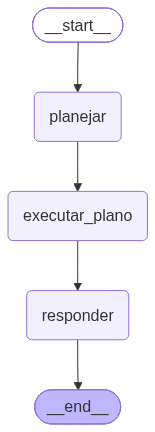

In [21]:
builder = StateGraph(EstadoReWOO)

builder.add_node("planejar", no_planejar_rewoo)
builder.add_node("executar_plano", no_executar_plano)
builder.add_node("responder", no_responder)

builder.add_edge(START, "planejar")
builder.add_edge("planejar", "executar_plano")
builder.add_edge("executar_plano", "responder")
builder.add_edge("responder", END)

graph_rewoo = builder.compile()

resultado_rewoo = graph_rewoo.invoke(
    {"tarefa": TAREFA, "plano": [], "evidencias": {}, "resposta": ""}
)

print("PLANO")
for passo in resultado_rewoo["plano"]:
    argumentos = ", ".join(f"{a.nome}={a.valor}" for a in passo.argumentos)
    print(f"  {passo.variavel} = {passo.ferramenta}({argumentos})")

print("-" * 70)
print("EVIDÊNCIAS")
for variavel, valor in resultado_rewoo["evidencias"].items():
    print(f"  {variavel}: {valor[:200]}")

print("-" * 70)
print("RESPOSTA")
print(resultado_rewoo["resposta"])

display_graph(graph_rewoo)

## 6.4 Leitura da execução

O plano gravado tem três passos, um por ferramenta. O primeiro recebe o literal `Renan`, extraído do texto da tarefa. O segundo recebe `#E1['modulo_atual']`, e o terceiro recebe `#E2['total_de_aulas']` e `#E1['minutos_por_semana']`, com o literal `4` no número de semanas.

As referências foram escritas antes de qualquer execução. No momento em que o planejador as produziu, nenhum dos valores existia: o modelo declarou de qual passo cada argumento viria, e não qual era o valor dele.

O nó `executar_plano` resolveu as três chamadas em sequência. Ao chegar ao terceiro passo, `evidencias` já tinha `#E1` e `#E2`, e `resolver_valor` extraiu 23 do JSON de `#E2` e 240 do JSON de `#E1`. As evidências impressas são as mesmas três strings JSON das seções anteriores.

A execução pelo `gemini-3.5-flash-lite` produziu os três mesmos passos, com as mesmas referências nos mesmos argumentos. A coincidência vem do esquema, que fixa a variável, o nome da ferramenta e a lista de argumentos de cada passo, e deixa ao modelo o preenchimento desses campos.

## 6.5 Discussão

O arranjo usa duas chamadas de modelo, uma para o plano e uma para a resposta, contra as seis da seção 4 na mesma tarefa. A diferença está no executor: aqui ele é uma função Python que substitui variáveis, e nas seções 4 e 5 é uma chamada de modelo por passo.

O planejador não recebe observação nenhuma. Uma evidência inesperada, como o código de erro de um aluno fora do cadastro, chega ao nó `responder` junto com as demais, e o plano segue até o fim como foi escrito. O arranjo cobre as tarefas cujos passos são determináveis a partir do enunciado, e a escolha de qual ferramenta chamar em cada passo se resolve antes de qualquer dado chegar.

A forma das referências é parte do contrato entre planejador e executor. O prompt declara as duas formas aceitas e a expressão regular reconhece exatamente essas duas, então um valor escrito em outro formato é tratado como literal e chega à ferramenta como texto.

---

# 7. Reflexão sobre o plano

O ciclo desta seção atua sobre o plano antes de a execução começar. Um nó propõe a lista de passos, um nó a critica contra critérios declarados, e a lista volta ao proponente enquanto houver ponto em aberto.

```text
START → propor → criticar ──── aprovado → END
           ↑         │
           └─────────┘  pontos em aberto e revisões disponíveis
```

O crítico recebe o mesmo catálogo de ferramentas e três critérios. O primeiro cobre a ordem das dependências, o segundo cobre a contingência de a carga não caber no tempo, e o terceiro cobre o formato da entrega. O contador `revisoes` limita o ciclo, porque a aprovação é uma saída do modelo e pode não chegar.

In [22]:
class Critica(BaseModel):
    """Avaliação de um plano antes da execução."""

    aprovado: bool = Field(description="true se o plano pode ser executado como está.")
    pontos: list[str] = Field(
        description="Problemas encontrados, um texto por item. Lista vazia quando aprovado."
    )


class EstadoReflexao(TypedDict):
    tarefa: str
    plano: list[str]
    pontos: list[str]
    aprovado: bool
    revisoes: int


PROMPT_CRITICO = f"""Avalie o plano proposto para a tarefa do aluno, sem executá-lo.
O executor do plano dispõe destas ferramentas:
{FERRAMENTAS_TEXTO}
Reprove o plano quando faltar qualquer um destes itens:
1. um passo que obtenha cada dado usado por um passo posterior;
2. um passo que decida o que estudar quando a carga não couber no tempo disponível;
3. um passo final que entregue a distribuição das aulas semana a semana.
Preencha os campos aprovado e pontos."""

LIMITE_REVISOES = 3

## 7.1 Nós do ciclo

O nó `propor` usa o mesmo `PROMPT_PLANEJADOR` da seção 4, e a mensagem do usuário muda entre a primeira versão e as demais. Na primeira, ela é a tarefa. Nas seguintes, ela traz também o plano anterior e os pontos apontados, o que dá ao modelo o texto a corrigir.

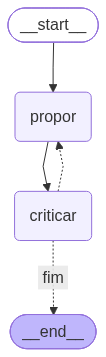

In [23]:
def no_propor_plano(state: EstadoReflexao) -> dict:
    """Escreve o plano, ou o reescreve a partir dos pontos apontados pelo crítico."""
    if state["pontos"]:
        pedido = (
            f"Tarefa: {state['tarefa']}\n\n"
            + "Plano anterior:\n" + "\n".join(f"- {passo}" for passo in state["plano"])
            + "\n\nProblemas apontados:\n" + "\n".join(f"- {p}" for p in state["pontos"])
            + "\n\nReescreva o plano corrigindo os problemas."
        )
    else:
        pedido = state["tarefa"]

    plano = invocar_estruturado(criar_estruturado(Plano), [
        SystemMessage(PROMPT_PLANEJADOR),
        HumanMessage(pedido),
    ])

    return {"plano": plano.passos, "revisoes": state["revisoes"] + 1}


def no_criticar_plano(state: EstadoReflexao) -> dict:
    """Aponta problemas do plano antes de qualquer ferramenta ser chamada."""
    critica = invocar_estruturado(criar_estruturado(Critica), [
        SystemMessage(PROMPT_CRITICO),
        HumanMessage(
            f"Tarefa: {state['tarefa']}\n\nPlano proposto:\n"
            + "\n".join(f"- {passo}" for passo in state["plano"])
        ),
    ])

    return {"aprovado": critica.aprovado, "pontos": [] if critica.aprovado else critica.pontos}


def decidir_revisao(state: EstadoReflexao) -> Literal["propor", "fim"]:
    """Devolve o plano ao proponente enquanto houver ponto aberto e revisão disponível."""
    if state["pontos"] and state["revisoes"] < LIMITE_REVISOES:
        return "propor"

    return "fim"


builder = StateGraph(EstadoReflexao)

builder.add_node("propor", no_propor_plano)
builder.add_node("criticar", no_criticar_plano)

builder.add_edge(START, "propor")
builder.add_edge("propor", "criticar")

builder.add_conditional_edges("criticar", decidir_revisao, {"propor": "propor", "fim": END})

graph_reflexao = builder.compile()

display_graph(graph_reflexao)

## 7.2 Execução do ciclo

A execução é acompanhada com `stream_mode="updates"`, e a saída alterna as duas formas de evento. O nó `propor` imprime o número da versão e os passos dela; o nó `criticar` imprime o valor de `aprovado` e os pontos apontados, que entram na mensagem da versão seguinte.

In [24]:
entrada = {"tarefa": TAREFA, "plano": [], "pontos": [], "aprovado": False, "revisoes": 0}

for evento in graph_reflexao.stream(entrada, stream_mode="updates"):
    for no, atualizacao in evento.items():
        if no == "propor":
            print(f"propor   | versão {atualizacao['revisoes']}")
            for indice, passo in enumerate(atualizacao["plano"], start=1):
                print(f"           {indice}. {passo}")
        else:
            print(f"criticar | aprovado={atualizacao['aprovado']}")
            for ponto in atualizacao["pontos"]:
                print(f"           - {ponto}")

propor   | versão 1
           1. Obter o módulo atual e os minutos de estudo por semana do Renan usando consultar_progresso('Renan')
           2. Com base no módulo atual, obter os módulos restantes e o total de aulas usando consultar_modulos_restantes(módulo_atual)
           3. Calcular a folga necessária para distribuir as aulas restantes nas 4 semanas usando calcular_folga(total_de_aulas, minutos_por_semana, 4)
           4. Apresentar ao Renan um plano de revisão semanal detalhado, indicando quantas aulas estudar por semana e o tempo diário recomendado
criticar | aprovado=False
           - O plano não inclui um passo que decida o que estudar ou ajuste a carga quando a quantidade de aulas não couber no tempo disponível.
propor   | versão 2
           1. Obter o módulo atual e os minutos de estudo por semana do Renan usando consultar_progresso('Renan')
           2. Com base no módulo atual, obter os módulos restantes e o total de aulas usando consultar_modulos_restantes(módulo_a

## 7.3 Leitura da execução

A primeira versão do plano tem quatro passos: as três consultas na ordem de dependência e a apresentação do plano ao aluno. O crítico a reprovou pelo segundo item da lista de critérios, e o ponto registrado é a ausência de um passo que decida o que estudar quando a carga exceder o tempo disponível. A segunda versão manteve os três primeiros passos e reescreveu os que faltavam, incorporando a decisão apontada. O crítico aprovou essa versão, e a rota encerrou o ciclo com `revisoes` em 2.

O critério que produziu a reprovação não está no prompt do proponente. `PROMPT_PLANEJADOR` pede no máximo quatro passos e descreve as ferramentas; a exigência de prever o caso em que a carga não cabe está apenas em `PROMPT_CRITICO`, e chegou ao proponente pelo texto do ponto apontado.

A execução pelo `gemini-3.5-flash-lite` reprovou a primeira versão por dois pontos, o segundo e o terceiro critérios, e aprovou a segunda. O número de pontos por versão sai de uma chamada de modelo e varia; o que se repete é a origem deles, que é a lista de critérios do prompt do crítico.

## 7.4 Discussão

Este ciclo e o replanejamento da seção 5 corrigem o plano em momentos diferentes. Aqui a correção acontece antes da primeira chamada de ferramenta, e o critério é um texto declarado na aplicação. Na seção 5 ela acontece durante a execução, e o gatilho é um valor observado.

Isso define o que cada um alcança. O crítico avalia a forma do plano, que é o único artefato disponível quando ele roda, e detecta um passo que usa um dado sem que nenhum passo anterior o obtenha. O replanejador avalia o plano contra um resultado já observado, e acrescenta o passo que essa evidência tornou necessário.

Os dois campos separados no esquema da crítica sustentam o ciclo. O booleano `aprovado` é lido pela rota, e a lista `pontos` entra na mensagem da revisão seguinte, sem que nenhum dos dois precise ser extraído do texto do outro.

O custo é de duas chamadas de modelo por versão do plano, e nenhuma ferramenta é executada nesta seção. O plano aprovado fica em `state["plano"]` como lista de strings, no mesmo formato que o nó `executar` das seções 4 e 5 consome.

---

# 8. Comparação dos arranjos

Os cinco arranjos executados neste notebook resolvem a mesma tarefa e diferem no lugar em que a sequência de passos fica e no momento em que ela pode mudar. A coluna de chamadas usa `k` para o número de passos do plano e `r` para o número de versões do ciclo de reflexão.

| Arranjo | Onde fica a sequência | Quando pode mudar | Chamadas de modelo | Observações no planejador |
|---|---|---|---|---|
| Laço por turno (seção 2) | histórico de mensagens | a cada turno, por decisão do modelo | 1 por turno | a cada turno |
| Plan-and-Execute (seção 4) | campo `plano` | não muda | 1 + `k` + 1 | nenhuma |
| Replanejamento (seção 5) | campo `plano` | durante a execução, por condição sobre a evidência | 1 + `k` + 1 + 1 | as coletadas até o desvio |
| ReWOO (seção 6) | campo `plano`, com referências | não muda | 2 | nenhuma |
| Reflexão (seção 7) | campo `plano` | entre versões, antes da execução | 2 × `r` | nenhuma |

Duas leituras da tabela orientam a escolha. A primeira é que o custo em chamadas segue o número de passos executados por modelo, e não a existência do plano: o ReWOO declara mais campos por passo que os outros quatro arranjos e faz duas chamadas, porque o executor dele é Python. A segunda é que o momento em que o plano pode mudar delimita o que o arranjo cobre, e a tabela abaixo liga situações a arranjos por essa coluna.

| Situação | Arranjo |
|---|---|
| Os passos saem do enunciado e as ferramentas não trazem surpresa | ReWOO |
| O plano precisa ser registrado ou aprovado antes de qualquer efeito | Plan-and-Execute |
| Um resultado intermediário pode exigir um passo que o enunciado não previa | Replanejamento |
| A aplicação tem critérios escritos que o plano precisa satisfazer | Reflexão sobre o plano |
| A tarefa tem poucos passos e cada um depende do anterior | Laço por turno |

Os arranjos se combinam, porque o campo `plano` tem o mesmo formato em quatro deles. O ciclo da seção 7 produz uma lista de strings que o nó `executar` da seção 5 consome, e o resultado é um plano criticado antes de executar e reescrito durante a execução.

---

# 9. Exercícios de fixação

Os exercícios modificam exemplos já executados, e a ordem deles é a ordem de execução das células. Os dois últimos com código alteram constantes que as células anteriores usam, então resolvê-los fora de ordem muda o resultado dos primeiros. Use as células vazias abaixo de cada enunciado.

## Exercício 1 — Teto de passos

Reatribua `LIMITE_PASSOS` para 2 e invoque `graph_replano` com a mesma entrada da subseção 5.2. Reporte quantos itens ficaram em `passos_feitos`, quantos itens tem o `plano` final, e se o nó `replanejar` chegou a ser executado. Devolva o valor 6 à constante ao fim da célula.

## Exercício 2 — Nós executados por arranjo

Invoque `graph_plano`, `graph_replano`, `graph_rewoo` e `graph_reflexao` com a mesma `TAREFA`, cada um com a entrada usada na sua seção, e percorra os quatro com `stream_mode="updates"`. Conte os eventos por nó em cada execução e reporte, para cada arranjo, quantos nós que chamam o modelo foram executados. Compare cada número com a coluna de chamadas de modelo da tabela da seção 8, onde `k` é o tamanho do plano no momento em que o executor o consome: no arranjo de replanejamento esse tamanho é o do plano revisto, e o teto `LIMITE_PASSOS` corta a contagem antes dele.

## Exercício 3 — Formatos de valor do ReWOO

Monte à mão um dicionário `evidencias` com as chaves `#E1` e `#E2`, associadas às strings JSON devolvidas por `consultar_progresso` e `consultar_modulos_restantes` na seção 1. Chame `resolver_valor` com quatro valores: `"Renan"`, `"4"`, `"#E1"` e `"#E2['total_de_aulas']"`. Reporte o tipo Python devolvido em cada caso.

## Exercício 4 — Critério a mais no crítico

Acrescente a `PROMPT_CRITICO` um quarto critério, exigindo que algum passo nomeie a quantidade de aulas de cada módulo restante. Invoque `graph_reflexao` com a entrada da subseção 7.2 e reporte quantas versões o ciclo produziu e qual foi o valor final de `aprovado`.

## Exercício 5 — Ferramenta a mais no plano

Escreva a ferramenta `consultar_material(codigo_modulo: str)`, que devolve em JSON dois materiais de apoio por módulo. Acrescente-a a `FERRAMENTAS_CURSO` e refaça as três construções que guardaram uma cópia da lista antiga: `FERRAMENTAS_POR_NOME`, o `bind_tools` de `modelo_executor` e o texto `FERRAMENTAS_TEXTO`, que foi interpolado em `PROMPT_PLANEJADOR` e exige reconstruir também esse prompt. Invoque `graph_plano` com a tarefa "Sou a Ana. Monte um plano de revisão de 4 semanas e inclua o material de apoio de cada módulo restante." e reporte se algum passo do plano citou a ferramenta nova.

## Exercício 6 — Escolha do arranjo

Sem executar código, indique qual dos cinco arranjos atende cada situação abaixo, usando as colunas de momento da mudança e de chamadas de modelo da seção 8. Justifique cada escolha em uma frase.

1. Um agente que apaga registros de um sistema acadêmico, e cujo plano precisa ser lido por uma pessoa antes de qualquer apagamento.
2. Um agente que responde quantas aulas tem um módulo, com uma consulta.
3. Um agente que monta o relatório semanal de 200 alunos, com os mesmos três passos para cada um, e cujo custo em tokens precisa cair.
4. Um agente cujo plano precisa satisfazer uma lista de exigências escritas pela coordenação do curso antes de rodar.

---

# 10. Resumo da aula

O notebook passou a sequência de ações de um agente do histórico de mensagens para um campo do estado, e percorreu os quatro arranjos que escrevem e alteram esse campo em momentos diferentes. Em todos eles o plano é uma lista de strings produzida por saída estruturada, e os arranjos diferem em quem a reescreve e com que informação.

| Conceito | Ideia principal |
|---|---|
| Plano | Lista ordenada de passos gravada em um campo do estado, escrita antes de qualquer execução. |
| Plan-and-Execute | Planejador, executor e conclusão em três nós, com a rota comparando passos feitos e tamanho do plano. |
| Reducer no estado | `operator.add` concatena o item novo, e o nó devolve apenas o que produziu. |
| Teto de passos | Contagem lida pela rota, que encerra a execução quando o tamanho do plano deixa de ser conhecido no início. |
| Replanejamento | Nó que troca os passos pendentes, alcançado por uma condição sobre a evidência já coletada. |
| Gatilho determinístico | Função Python sobre o texto das evidências, que decide o desvio sem chamar o modelo. |
| ReWOO | Plano escrito em uma chamada, com referências `#E1` e `#E1['campo']` resolvidas por um executor sem modelo. |
| Reflexão sobre o plano | Ciclo de proposta e crítica que corrige a lista de passos antes da primeira chamada de ferramenta. |
| `method="function_calling"` | Forma de saída estruturada aceita pelos dois provedores do notebook. |
| Retorno vazio do parser | `None` no lugar do objeto, tratado por repetição da chamada. |

## 10.1 Checklist de compreensão

Questões de verificação:

1. O que distingue a sequência de ações de um laço por turno da sequência gravada em um campo `plano`?
2. Como o executor localiza o passo atual sem um campo próprio para o índice?
3. Por que os campos `passos_feitos` e `evidencias` recebem um reducer, e o campo `plano` não?
4. Que condição a rota da seção 5 avalia antes de comparar o número de passos, e por que o campo `replanejado` é necessário?
5. Por que o tamanho do plano é conhecido no início do grafo da seção 4 e não no da seção 5, e o que o teto de passos limita nesse segundo caso?
6. O que uma referência `#E1['campo']` designa no momento em que o planejador do ReWOO a escreve?
7. Quantas chamadas de modelo o ReWOO faz para uma tarefa de três passos, e por que esse número não cresce com o número de passos?
8. Que tipo de defeito o crítico da seção 7 detecta, e que tipo de defeito só o replanejador da seção 5 alcança?

## 10.2 Próximos passos

- Interrupção do grafo entre o planejador e o executor, com o plano submetido a aprovação humana antes de qualquer efeito externo;
- persistência do plano por `thread_id`, que permite retomar uma execução interrompida no passo em que ela parou;
- execução em paralelo dos passos de um plano ReWOO que não dependem uns dos outros;
- verificação do plano por uma função Python, no lugar do crítico gerado por modelo;
- medição de tokens e latência por arranjo sobre um conjunto de tarefas com resposta conhecida;
- decomposição hierárquica, com um passo do plano expandido em um plano próprio.

---

# 11. Referências

- Wang et al., Plan-and-Solve Prompting: https://arxiv.org/abs/2305.04091
- Xu et al., ReWOO: Decoupling Reasoning from Observations for Efficient Augmented Language Models: https://arxiv.org/abs/2305.18323
- Shinn et al., Reflexion: Language Agents with Verbal Reinforcement Learning: https://arxiv.org/abs/2303.11366
- Yao et al., ReAct: Synergizing Reasoning and Acting in Language Models: https://arxiv.org/abs/2210.03629
- LangGraph, Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- LangChain, saída estruturada: https://docs.langchain.com/oss/python/langchain/structured-output
- LangChain, ferramentas: https://docs.langchain.com/oss/python/langchain/tools
- Referência de API, `StateGraph`: https://reference.langchain.com/python/langgraph/graph/StateGraph
- Referência de API, `ChatOllama`: https://reference.langchain.com/python/langchain-ollama/chat_models/ChatOllama
- Referência de API, `ChatGoogleGenerativeAI`: https://reference.langchain.com/python/langchain-google-genai/chat_models/ChatGoogleGenerativeAI
- Ollama, documentação: https://docs.ollama.com
- Gemini, controle de raciocínio: https://ai.google.dev/gemini-api/docs/thinking